# Missing and spurious interactions and the reconstruction of complex networks

---

**Students**
* Gabriele Bellavia (Badge No. )
* Sofia Di Lucia (Badge No. 2149752)

**Academic Year:** 2025–2026

---

- [Ref article](https://www.pnas.org/doi/10.1073/pnas.0908366106)
- I dataset citati dovrebbero essere questi:
    1. [karate club (23)](https://networkrepository.com/soc-karate.php)
    2. [dolphins (24)](https://networkrepository.com/dolphins.php)
    3. [air transportation network of Eastern Europe (25)](https://www.oag.com/flight-data-sets)
    4. [Caenorhabditis elegans (26)](http://konect.cc/networks/dimacs10-celegansneural/)
    5. [metabolic network of Escherichia coli (27, 28)](http://bigg.ucsd.edu/models/iJR904)
- Altri dataset:
    1. [SNAP](https://snap.stanford.edu/data/#socnets)
    2. [Network Repository](https://networkrepository.com/)
- Software and libraries:
    1. [igraph](https://igraph.org/)
    2. [networkx](https://networkx.org/en/)
    3. [graphtool](https://graph-tool.skewed.de/)
    4. [Gephi](https://gephi.org/)

In [141]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(123)

## Inspecting networks 

Graph named "Zachary's Karate Club" with 34 nodes and 78 edges


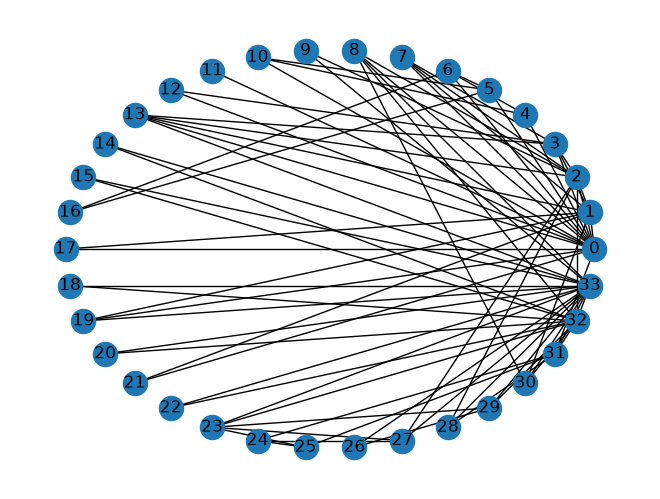

In [7]:
G = nx.karate_club_graph()
print(G)
nx.draw_circular(G, with_labels=True)
plt.show()

In [8]:
AT = nx.adjacency_matrix(G).toarray()

(pag.2 article):<br>
1. we assume that each of these networks is the “true” network $A^T$ and is error free
2. We then generate hypothetical observations $A^O$ by adding or removing random connections from $A^T$
3. We evaluate the ability of our approach to recover the features of the true network

- **missing(\spurious) interactions**:
1. we generate observed networks $A^O$ by removing(\adding) random links from the true network $A^T$
2. We then estimate the link reliability $R^L_{ij}$ for each of these false negatives ($A^O_{ij} = 0$ and $A^T_{ij} = 1$), as well as for the
true negatives ($A^O_{ij} = 0$ and $A^T_{ij} = 0$) (\spurious: false positive ($A^O_{ij} = 1$ and $A^T_{ij} = 0$) is ranked lower than a true positive ($A^O_{ij} = 1$ and $A^T_{ij} = 1$).)
3. We measure the algorithm’s ability to identify missing interactions by ranking the reliabilities (in decreasing order) and calculating the probability that a false negative has a higher ranking than a true negative. 

We need to compute R, to do so, because we can't compute all the possible partitions P, we use the Metropolis algorithm to sample relevant partitions.

## Metropolis Estimation

We start by placing each of the N nodes in a group, which we choose
with uniform probability from a set of N possible groups (that is, there are
as many groups as nodes). In general, some of these N groups will be empty
after the initial node assignment

In [149]:
# creating the N possible groups
N = len(G.nodes)
groups = {}
for i in range(N):
    groups.update({
        f'group {i}': []
    })

# placing each node in a group
assign = np.array(np.random.randint(0, N, N, dtype=int))
for i in G.nodes:
    group_ass = assign[i]
    groups[f'group {group_ass}'].append(i)

At each step we select a random node and attempt to move it to a randomly selected group:
- if $\Delta H \le 0 \rightarrow$ we accept the move
- if $\Delta H \ge 0 \rightarrow$ we accep the move with $P = e^{- \Delta H}$
with
```math
H(P) = \sum_{\alpha \le \beta} \Big[\ln(r_{\alpha \beta}+1) + \ln\binom{r_{\alpha \beta}}{l^O_{\alpha \beta}} \Big]
```
where:
- $\alpha$ and $\beta$ are groups
- $r_{\alpha \beta}$ is the maximum possible number of links between $\alpha$ and $\beta$
- $l^O_{\alpha \beta}$ is the number of links in the observed network between $\alpha$ and $\beta$

In [ ]:
# function to calculate r_ab
def compute_r_ab(alpha, beta):
    alpha_size = len(groups[f'group {alpha}'])
    beta_size = len(groups[f'group {beta}'])
    return alpha_size * beta_size

In [ ]:
# TO DO: finish to define this function
def compute_l_ab(alpha, beta):
    print(f"Alpha: {groups[f'group {alpha}']}")
    print(f"Beta: {groups[f'group {beta}']}")
    #list(G.edges)
    return

compute_l_ab(alpha, beta)

Alpha: [12, 18]
Beta: [1, 20]


In [ ]:
for step in range(1):
    rand_node = np.random.randint(0, N, dtype=int)
    # beta is the proposed move group
    beta = np.random.randint(0, N, dtype=int)
    alpha = assign[rand_node]
    print(f'Selected node: {rand_node}. From group {alpha} move to group {beta}')

    # we need to compute delta-H
    r_ab = compute_r_ab(alpha, beta)
    

Selected node: 12. From group 29 move to group 12
